# Notebook 4: Hailo Compilation & Profiling

This notebook compiles the quantized HAR model into a HEF (Hailo Executable Format) file
that can run directly on Hailo-8L hardware.

**Steps:**
1. Load the quantized HAR from Notebook 3
2. Compile to HEF binary
3. Run the Hailo profiler for performance estimates
4. Model size comparison across the full pipeline
5. Performance summary (FPS, latency, memory)

## 1. Setup & Imports

In [1]:
import os
import time
from pathlib import Path

import matplotlib
# Compatibility shim for newer Matplotlib with older matplotlib-inline builds.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__
import matplotlib.pyplot as plt
import numpy as np

try:
    from hailo_sdk_client import ClientRunner
    HAILO_SDK_AVAILABLE = True
    HAILO_SDK_IMPORT_ERROR = None
except Exception as exc:
    ClientRunner = None
    HAILO_SDK_AVAILABLE = False
    HAILO_SDK_IMPORT_ERROR = exc

WORKSPACE = Path("/home/appuser/Hailo-Training")
MODELS_DIR = WORKSPACE / "models"

NET_NAME = "doclaynet_yolo26n"
QUANTIZED_HAR_PATH = str(MODELS_DIR / f"{NET_NAME}_quantized.har")
COMPILED_HAR_PATH = str(MODELS_DIR / f"{NET_NAME}_compiled.har")
HEF_PATH = str(MODELS_DIR / f"{NET_NAME}.hef")

assert os.path.exists(QUANTIZED_HAR_PATH), (
    f"Quantized HAR not found: {QUANTIZED_HAR_PATH}. Run Notebook 3 first."
)
print(f"Quantized HAR: {QUANTIZED_HAR_PATH}")
print(f"Output HEF: {HEF_PATH}")
if not HAILO_SDK_AVAILABLE:
    print(f"Warning: hailo_sdk_client is unavailable in this session: {HAILO_SDK_IMPORT_ERROR}")
    print("Compilation/profiling cells will be skipped unless the environment is fixed.")

E0000 00:00:1774504171.549445   33965 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774504171.554070   33965 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Quantized HAR: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har
Output HEF: /home/appuser/Hailo-Training/models/doclaynet_yolo26n.hef


## 2. Load Quantized Model

In [2]:
if not HAILO_SDK_AVAILABLE:
    raise RuntimeError(
        "hailo_sdk_client is unavailable. Fix the environment and re-run Cell 3 before continuing."
    )

runner = ClientRunner(har=QUANTIZED_HAR_PATH)
# The hw_arch is embedded in the HAR from the optimization step
print(f"Loaded quantized model from: {QUANTIZED_HAR_PATH}")
print(f"Model is ready for compilation.")

Loaded quantized model from: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_quantized.har
Model is ready for compilation.


## 3. Compile to HEF

The compiler maps the quantized model onto the Hailo-8L's neural processing unit (NPU).
This step optimizes data flow, memory allocation, and layer scheduling for maximum
throughput on the hardware.

**This can take several minutes** depending on model complexity.

In [3]:
print("Compiling model to HEF...")
print("This may take several minutes.\n")

t0 = time.time()
hef = runner.compile()
compile_time = time.time() - t0

# Save HEF file
with open(HEF_PATH, "wb") as f:
    f.write(hef)

hef_size_mb = os.path.getsize(HEF_PATH) / (1024 * 1024)
print(f"\nCompilation completed in {compile_time:.1f}s ({compile_time/60:.1f} min)")
print(f"HEF saved to: {HEF_PATH}")
print(f"HEF size: {hef_size_mb:.1f} MB")

Compiling model to HEF...
This may take several minutes.

[info] To achieve optimal performance, set the compiler_optimization_level to "max" by adding performance_param(compiler_optimization_level=max) to the model script. Note that this may increase compilation time.
[info] Loading network parameters
[info] Starting Hailo allocation and compilation flow
[info] Building optimization options for network layers...
[info] Successfully built optimization options - 7s 905ms
[info] Trying to compile the network in a single context
[info] Single context flow failed: Recoverable single context error
[info] Building optimization options for network layers...
[info] Successfully built optimization options - 10s 556ms
[info] Using Multi-context flow
[info] Resources optimization params: max_control_utilization=60%, max_compute_utilization=60%, max_compute_16bit_utilization=60%, max_memory_utilization (weights)=60%, max_input_aligner_utilization=60%, max_apu_utilization=60%
[info] Finding the bes

## 4. Save Compiled HAR & Run Profiler

In [4]:
# Save compiled HAR (includes profiling info)
runner.save_har(COMPILED_HAR_PATH)
compiled_har_size_mb = os.path.getsize(COMPILED_HAR_PATH) / (1024 * 1024)
print(f"Compiled HAR saved: {COMPILED_HAR_PATH} ({compiled_har_size_mb:.1f} MB)")

[info] Saved HAR to: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_compiled.har
Compiled HAR saved: /home/appuser/Hailo-Training/models/doclaynet_yolo26n_compiled.har (64.5 MB)


In [5]:
# Run Hailo profiler — generates an HTML report with performance estimates
print("Running Hailo Profiler...")
print("This generates a detailed HTML report with FPS, latency, and layer utilization.\n")
!hailo profiler {COMPILED_HAR_PATH} --no-browser 2>&1 | tail -30

Running Hailo Profiler...
This generates a detailed HTML report with FPS, latency, and layer utilization.

[info] 
Model Details
--------------------------------  ----------
Input Tensors Shapes              640x640x3
Operations per Input Tensor       5.33 GOPs
Operations per Input Tensor       2.68 GMACs
Pure Operations per Input Tensor  5.33 GOPs
Pure Operations per Input Tensor  2.68 GMACs
Model Parameters                  2.88 M
--------------------------------  ----------

Profiler Input Settings
-----------------  -----------------
Optimization Goal  Reach Highest FPS
Profiler Mode      Compiled
-----------------  -----------------

Performance Summary
----------------------  ---
Number of Devices       1
Number of Contexts      6
Throughput              N/A
Latency                 N/A
Operations per Second   N/A
MACs per Second         N/A
Total Input Bandwidth   N/A
Total Output Bandwidth  N/A
Context Switch Configs  N/A
----------------------  ---
[info] Saved Profiler HTML Re

## 5. Model Size Comparison

Track the model size across every stage of the pipeline.

In [6]:
# Collect sizes for all model formats
size_data = {}

format_paths = {
    "PyTorch (.pt)": MODELS_DIR / "best.pt",
    "ONNX (.onnx)": MODELS_DIR / "best.onnx",
    "ONNX Simplified": MODELS_DIR / "best_simplified.onnx",
    "HAR (parsed)": MODELS_DIR / f"{NET_NAME}.har",
    "HAR (quantized)": MODELS_DIR / f"{NET_NAME}_quantized.har",
    "HAR (compiled)": MODELS_DIR / f"{NET_NAME}_compiled.har",
    "HEF (final)": MODELS_DIR / f"{NET_NAME}.hef",
}

print(f"{'Format':<25} {'Size (MB)':<15} {'Status'}")
print("=" * 55)
for label, path in format_paths.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        size_data[label] = size_mb
        print(f"{label:<25} {size_mb:<15.2f} OK")
    else:
        print(f"{label:<25} {'—':<15} Not found")

Format                    Size (MB)       Status
PyTorch (.pt)             5.15            OK
ONNX (.onnx)              9.36            OK
ONNX Simplified           9.27            OK
HAR (parsed)              9.70            OK
HAR (quantized)           53.63           OK
HAR (compiled)            64.46           OK
HEF (final)               10.69           OK


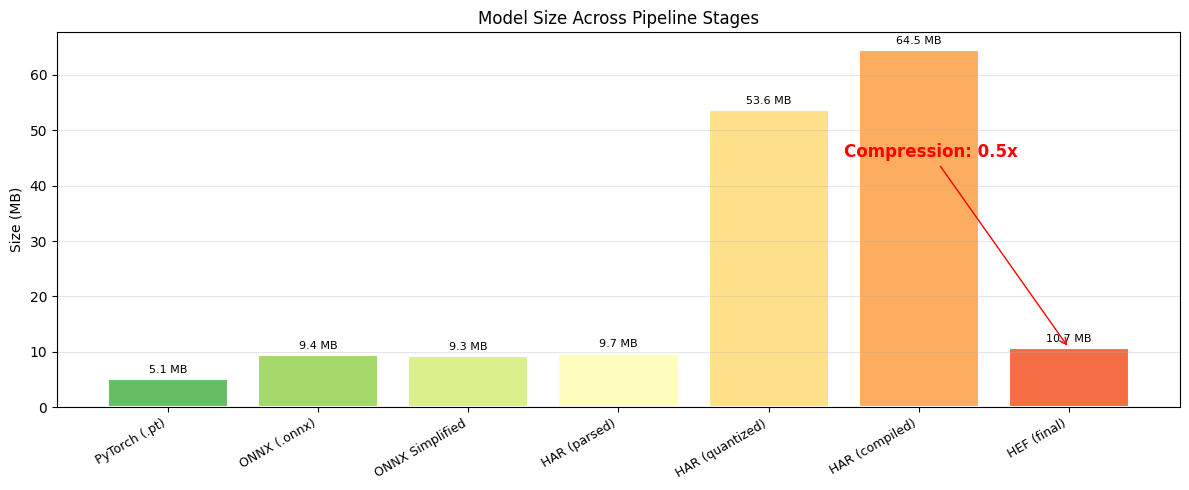

In [7]:
# Plot model size progression
if size_data:
    fig, ax = plt.subplots(figsize=(12, 5))

    labels = list(size_data.keys())
    sizes = list(size_data.values())
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(labels)))

    bars = ax.bar(range(len(labels)), sizes, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Size (MB)")
    ax.set_title("Model Size Across Pipeline Stages")
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(bars, fmt="%.1f MB", padding=3, fontsize=8)

    # Add compression ratio annotation
    if "PyTorch (.pt)" in size_data and "HEF (final)" in size_data:
        ratio = size_data["PyTorch (.pt)"] / size_data["HEF (final)"]
        ax.annotate(
            f"Compression: {ratio:.1f}x",
            xy=(len(labels) - 1, size_data["HEF (final)"]),
            xytext=(len(labels) - 2.5, max(sizes) * 0.7),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=12, color="red", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

## 6. Performance Summary

In [8]:
print("=" * 60)
print("COMPILATION SUMMARY")
print("=" * 60)
print(f"Model:              {NET_NAME}")
print(f"Input resolution:   640 x 640")
print(f"Classes:            11 (document layout)")
print(f"Quantization:       INT8 (PTQ)")
print(f"Compile time:       {compile_time:.1f}s")
print(f"")
print(f"Model sizes:")
for label, size in size_data.items():
    print(f"  {label:<25} {size:.2f} MB")
print(f"")
print(f"HEF file: {HEF_PATH}")
print(f"")
print(f"The HEF file is ready for deployment on Hailo-8L hardware.")
print(f"Check the profiler HTML report for detailed FPS and latency estimates.")
print(f"")
print(f"Next step: Run 05_Inference_and_Benchmarking.ipynb")

COMPILATION SUMMARY
Model:              doclaynet_yolo26n
Input resolution:   640 x 640
Classes:            11 (document layout)
Quantization:       INT8 (PTQ)
Compile time:       491.3s

Model sizes:
  PyTorch (.pt)             5.15 MB
  ONNX (.onnx)              9.36 MB
  ONNX Simplified           9.27 MB
  HAR (parsed)              9.70 MB
  HAR (quantized)           53.63 MB
  HAR (compiled)            64.46 MB
  HEF (final)               10.69 MB

HEF file: /home/appuser/Hailo-Training/models/doclaynet_yolo26n.hef

The HEF file is ready for deployment on Hailo-8L hardware.
Check the profiler HTML report for detailed FPS and latency estimates.

Next step: Run 05_Inference_and_Benchmarking.ipynb
